# Task 4 - Visualization

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
import seaborn

## Import csv data

In [2]:
customers = pd.read_csv('Data/train_data.csv')
customers['subscription_start'] = pd.to_datetime(customers['subscription_start'])
customers['subscription_end'] = pd.to_datetime(customers['subscription_end'])
customers

,id,birth_date,age,gender,subscription_start,subscription_end,subscription_length,avg_invoice,total_invoices,sms,sms_roam,data,data_roam,phone_calls,calls_roam,churn
0,0,1986-10-30,32,F,2010-08-18,2018-01-01,2693,49.805556,1793,2.506069,0.211018,127.529563,0.634961,315.273859,0.096266,False
1,1,1967-03-22,51,M,1997-07-05,2018-01-01,7485,43.694444,1573,2.523311,0.186489,128.289575,0.665380,305.975507,0.086149,False
2,2,1965-12-25,53,M,2003-05-23,2018-01-01,5337,49.805556,1793,2.542373,0.209372,127.429825,0.677945,314.724333,0.110752,False
3,3,1988-06-17,30,F,2013-09-14,2018-01-01,1570,44.083333,1587,2.516370,0.210477,130.208955,0.686567,298.559564,0.092282,False
4,4,1964-12-18,54,M,2004-01-28,2018-01-01,5087,45.500000,1638,2.575605,0.201613,132.553665,0.680628,301.945813,0.094417,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,1962-08-11,56,M,2003-05-31,2018-01-01,5329,43.194444,1555,2.568411,0.219467,126.781638,0.668734,294.975382,0.079796,False
996,996,1987-12-10,31,F,2007-11-18,2018-01-01,3697,43.777778,1576,2.577132,0.230490,146.413669,0.685851,304.665543,0.082561,False
997,997,1989-10-24,29,F,2007-10-24,2017-12-13,3703,41.388889,1490,2.504845,0.206395,132.770574,0.670823,206.115166,0.105434,True
998,998,1980-04-04,38,F,2013-10-03,2018-01-01,1551,48.638889,1751,2.707823,0.200754,143.475309,0.656790,296.846416,0.103242,False


In [3]:
numerical_features = ['age', 'avg_invoice', 'total_invoices', 'sms', 'sms_roam', 'phone_calls', 'calls_roam', 'data', 'data_roam']
customers[numerical_features].describe()

,age,avg_invoice,total_invoices,sms,sms_roam,phone_calls,calls_roam,data,data_roam
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.432000,43.366233,1460.668000,2.541894,0.209882,295.758465,0.090903,133.672087,0.665894
std,14.795347,7.550720,426.013992,0.086338,0.021872,24.857021,0.011701,6.393344,0.018976
min,29.000000,0.000000,0.000000,2.041667,0.000000,31.000000,0.000000,47.000000,0.500000
25%,40.000000,41.743056,1479.000000,2.493526,0.201372,292.885405,0.084945,130.582476,0.655650
50%,54.000000,44.666667,1600.500000,2.540827,0.210078,301.406791,0.090345,133.727935,0.666261
75%,66.000000,47.250000,1694.000000,2.586259,0.219426,308.144422,0.096532,137.219237,0.676822
max,79.000000,79.000000,2008.000000,3.312500,0.416667,383.285714,0.186047,161.984615,0.772727


## Plot histograms

array([[<AxesSubplot:title={'center':'age'}>,
        <AxesSubplot:title={'center':'avg_invoice'}>,
        <AxesSubplot:title={'center':'calls_roam'}>],
       [<AxesSubplot:title={'center':'data'}>,
        <AxesSubplot:title={'center':'data_roam'}>,
        <AxesSubplot:title={'center':'phone_calls'}>],
       [<AxesSubplot:title={'center':'sms'}>,
        <AxesSubplot:title={'center':'sms_roam'}>,
        <AxesSubplot:title={'center':'total_invoices'}>]], dtype=object)

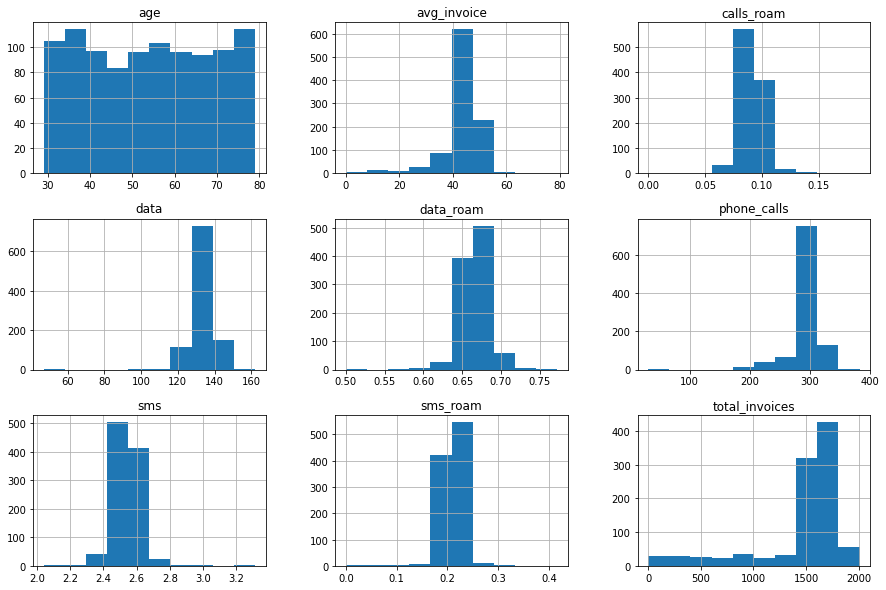

In [4]:
customers[numerical_features].hist(figsize=(15, 10))

array([<AxesSubplot:title={'center':'age'}>,
       <AxesSubplot:title={'center':'avg_invoice'}>,
       <AxesSubplot:title={'center':'calls_roam'}>,
       <AxesSubplot:title={'center':'data'}>,
       <AxesSubplot:title={'center':'data_roam'}>,
       <AxesSubplot:title={'center':'phone_calls'}>,
       <AxesSubplot:title={'center':'sms'}>,
       <AxesSubplot:title={'center':'sms_roam'}>,
       <AxesSubplot:title={'center':'total_invoices'}>], dtype=object)

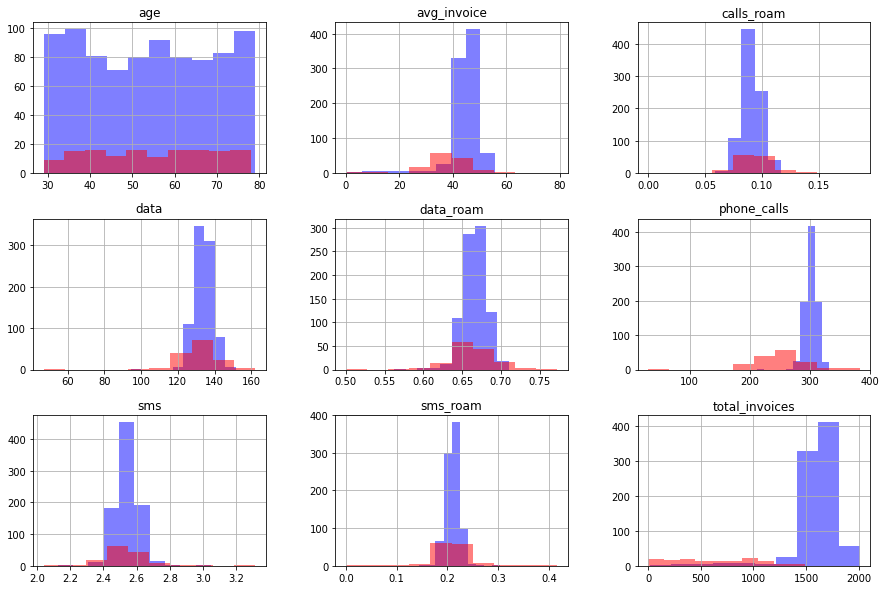

In [5]:
fig, ax = plt.subplots(3, 3, figsize=(15, 10))
customers[customers['churn'] == False][numerical_features].hist(color='blue', alpha=0.5, ax=ax)
customers[customers['churn'] == True][numerical_features].hist(color='red', alpha=0.5, ax=ax)

## Plot churners based on subscription length

In [6]:
percent_25 = 1945
percent_50 = 3574
percent_75 = 5779
customers25 = customers[customers['subscription_length'] <= percent_25]
customers50 = customers[(customers['subscription_length'] > percent_25) & (customers['subscription_length'] <= percent_50)]
customers75 = customers[(customers['subscription_length'] > percent_50) & (customers['subscription_length'] <= percent_75)]
customers75plus = customers25 = customers[customers['subscription_length'] > percent_75]

Text(0.5, 1.0, '75%+')

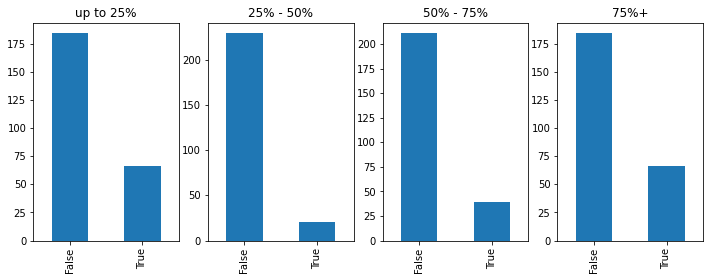

In [7]:
fig, ax = plt.subplots(1, 4, figsize=(12, 4))
customers25['churn'].value_counts().plot(kind='bar', ax=ax[0]).set_title('up to 25%')
customers50['churn'].value_counts().plot(kind='bar', ax=ax[1]).set_title('25% - 50%')
customers75['churn'].value_counts().plot(kind='bar', ax=ax[2]).set_title('50% - 75%')
customers75plus['churn'].value_counts().plot(kind='bar', ax=ax[3]).set_title('75%+')

Only 16.55% are churners


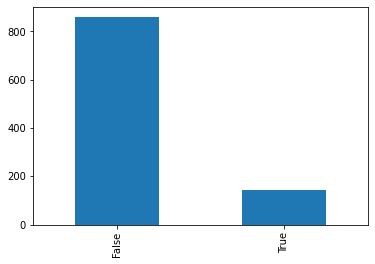

In [8]:
total_churns = customers['churn'].value_counts()
total_churns.plot(kind='bar')
print(f'Only {round(total_churns[1] / total_churns[0] * 100, 3)}% are churners')

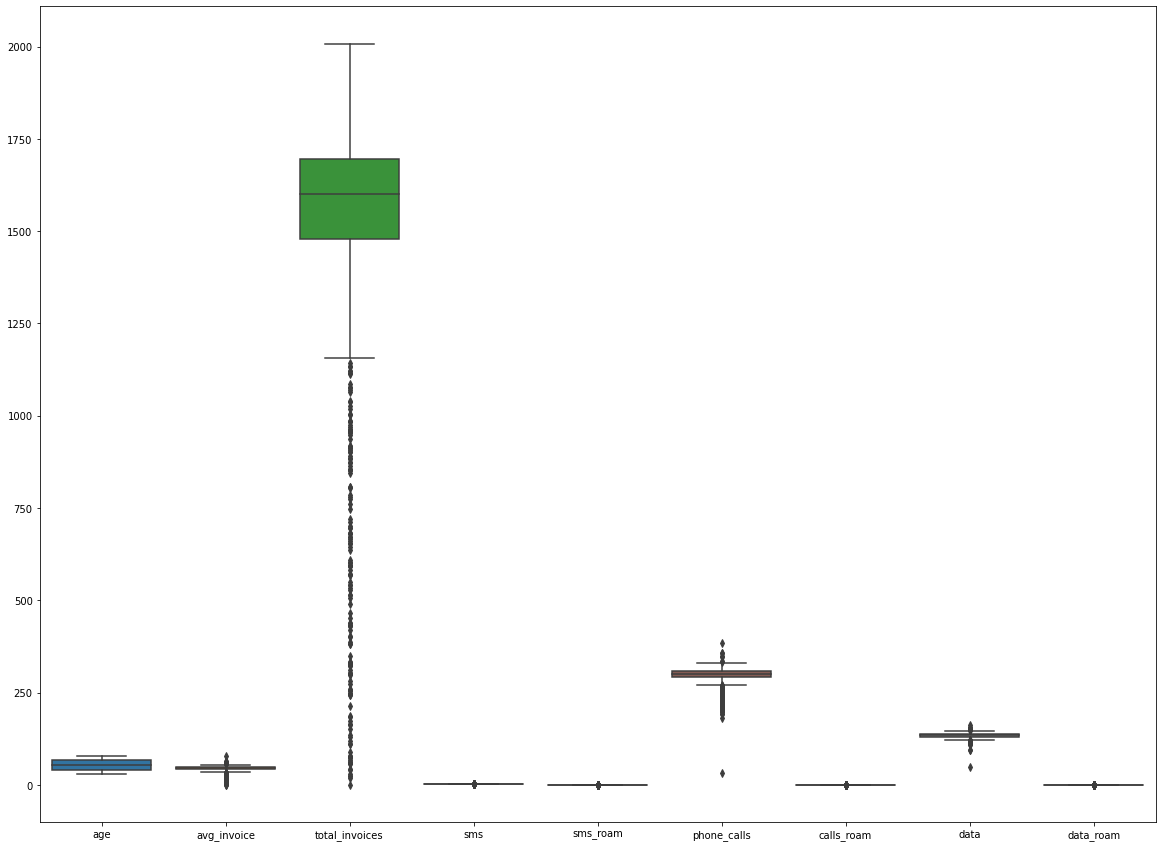

In [9]:
plt.figure(figsize=(20, 15))
seaborn.boxplot(data=customers[numerical_features])
plt.show()